<a href="https://colab.research.google.com/github/Gaurav8605/Codsoft/blob/main/linearregression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns


In [2]:
df =pd.read_csv('/content/Simple_Linear_regression_dataset.csv')
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


Text(0, 0.5, 'Height')

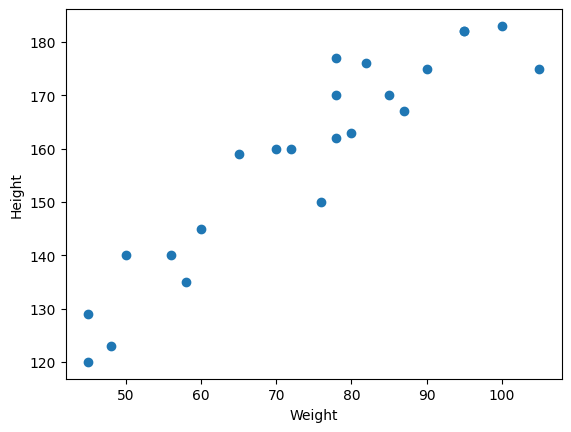

In [3]:
plt.scatter(df['Weight'],df['Height'])
plt.xlabel('Weight')
plt.ylabel('Height')


In [4]:
df.corr()

,Weight,Height
Weight,1.000000,0.931142
Height,0.931142,1.000000


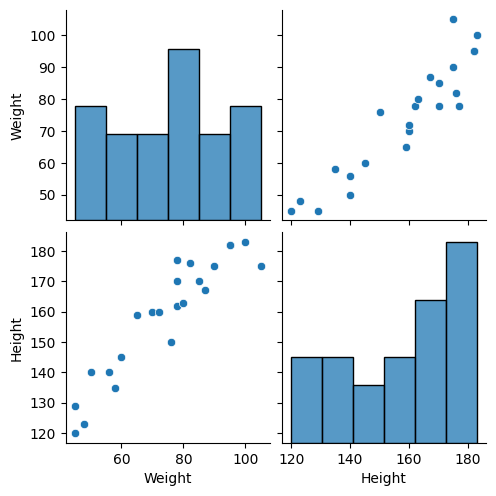

In [5]:
import seaborn as sns
sns.pairplot(df)

In [6]:
x = df['Weight']
np.array(x).shape
y = df['Height']

In [7]:
y

,Height
0,120
1,135
2,123
3,145
4,160
5,162
6,163
7,175
8,182
9,170


In [8]:
np.array(y).shape

(23,)

In [9]:
from sklearn.model_selection import train_test_split

In [10]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.25,random_state=42)

In [11]:
x_train.shape

(17,)

In [13]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_train = sc.fit_transform(x_train.values.reshape(-1, 1))

In [14]:
x_train

array([[-0.87662801],
       [ 1.66773133],
       [ 0.33497168],
       [-1.48242785],
       [ 1.36483141],
       [-1.6641678 ],
       [-0.75546804],
       [-0.1496682 ],
       [ 0.21381171],
       [-1.36126788],
       [-0.99778797],
       [-0.02850823],
       [ 1.06193149],
       [ 0.57729161],
       [ 0.75903157],
       [ 0.88019153],
       [ 0.45613165]])

In [16]:
x_test = sc.transform(x_test.values.reshape(-1, 1))

In [15]:
x_test

,Weight
15,78
9,78
0,45
8,95
17,65
12,105


In [17]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()

In [18]:
lr.fit(x_train.reshape(-1, 1),y_train)

LinearRegression()

In [19]:
lr

LinearRegression()

In [20]:
print("Coefficient or slope :", lr.coef_)
print("Intercept :", lr.intercept_)

Coefficient or slope : [17.2982057]
Intercept : 156.47058823529412


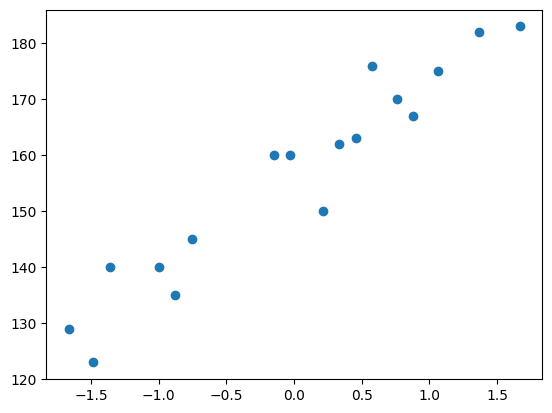

In [21]:
plt.scatter(x_train, y_train)

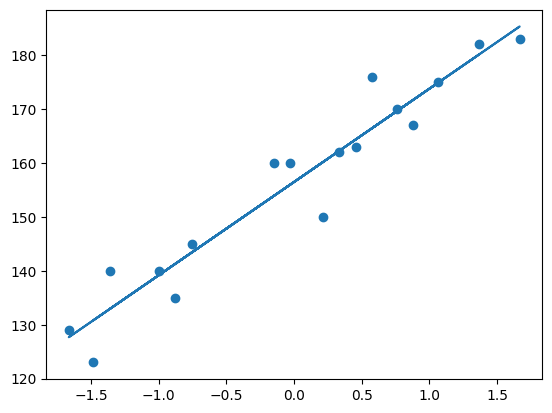

In [22]:
plt.scatter(x_train, y_train)
plt.plot(x_train, lr.predict(x_train))

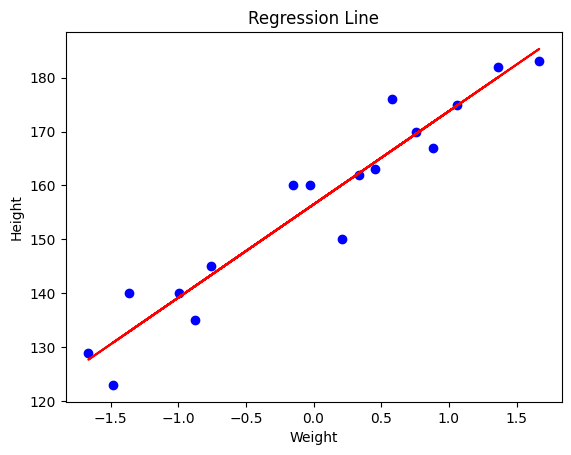

In [23]:
plt.scatter(x_train, y_train, color='blue')
plt.plot(x_train, lr.predict(x_train), color='red')
plt.xlabel("Weight")
plt.ylabel("Height")
plt.title("Regression Line")
plt.show()

In [24]:
y_pred = lr.predict(x_test)

In [31]:
y_pred

array([162.26499721, 162.26499721, 127.68347133, 180.07972266,
       148.64197186, 190.55897293])

In [25]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [26]:
mse = mean_squared_error(y_test, y_pred)

In [27]:
mae = mean_absolute_error(y_test, y_pred)

In [28]:
rmse = np.sqrt(mse)

In [29]:
print("MSE=",mse)
print("MAE=",mae)
print("RMSE=",rmse)

MSE= 114.84069295228699
MAE= 9.66512588679501
RMSE= 10.716374991212605


MSE (Mean Squared Error)

MAE (Mean Absolute Error)

RMSE (Root Mean Squared Error)

In [30]:
from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_pred)
print(r2)

0.7360826717981276


In [33]:
X_test_reshaped = x_test.reshape(-1, 1)
adjusted_r2 = 1 - (1 - r2) * (len(y_test) - 1) / (len(y_test) - X_test_reshaped.shape[1] - 1)
print("Adjusted R2=", adjusted_r2)

Adjusted R2= 0.6701033397476595


In [35]:
import statsmodels.api as sm

model = sm.OLS(y_train, x_train).fit()

In [36]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:                 Height   R-squared (uncentered):                   0.012
Model:                            OLS   Adj. R-squared (uncentered):             -0.050
Method:                 Least Squares   F-statistic:                             0.1953
Date:                Tue, 10 Mar 2026   Prob (F-statistic):                       0.664
Time:                        07:26:25   Log-Likelihood:                         -110.03
No. Observations:                  17   AIC:                                      222.1
Df Residuals:                      16   BIC:                                      222.9
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [40]:
lr.predict(sc.transform([[45]]))

array([127.68347133])